# 5. Slide figures

Figures for talks, at one grid point and season of one model: the forcings revealed one at a time (a frame per step, all with the same axes so they can be flipped through), and the historical and hist-nat ensembles as members and as quantile plumes. Then, at the end, how the forced-response figures of notebooks 04 and 06 are made: how a count of models comes from one test per model, what the 3 × 3 colours of the joint maps mean, and the forcings' changes revealed one at a time. Everything is saved under `figures/<variable>/slides/` in this repository.

Names end in their type: `_tree` (DataTree), `_ds` (Dataset), `_da` (DataArray), `_arr` (numpy array), `_df` (DataFrame).

## Setup

In [1]:
import sys
sys.path[:0] = ['..']   # this repository: the extant package and plotting_modules

import logging
import warnings
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from dask.distributed import wait
from plotting_modules import formatting, maps
from extant import config, loading, paths, preprocessing as pp, storage
from extant.logger import setup_logging
from extant.plots import methods

logger = setup_logging('extant', logging.INFO)
xr.set_options(display_expand_attrs=False, display_expand_data=False)

#(t): Dask warns about every large task graph; the graphs here are large on purpose
warnings.filterwarnings('ignore', message='.*Sending large graph of size.*', category=UserWarning)

from functools import partial

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from plotting_modules import figures, timeseries, utils
from plotting_modules.constants import FORCING_COLORS, FORCING_REVEAL_ORDER, SLIDE_RC
from extant import datatree, quantiles as qc
from extant.plots.slides import label_band_edges, label_line_end
from extant import significance as sig
from extant.plots import forced_response as fr, slides

In [2]:
%matplotlib inline

## Settings

In [3]:
VARIABLE = 'tas'
var = config.VARIABLES[VARIABLE]

SLIDE_MODEL = config.PLOT_SEL['model']
SLIDE_SEASON = 'DJF'
SLIDE_POINT = config.POINT
SLIDE_DIR = paths.figure('slides', VARIABLE)
SLIDE_DIR.mkdir(exist_ok=True)
POINT_LABEL = formatting.format_latlon(SLIDE_POINT)

#(t): For the forced-response figures (the end of this notebook): the experiment shown, the forcings, the
#(t): seasons, the final years, the significance level and the fraction of models that makes a change robust
SLIDE_EXPERIMENT = config.PLOT_SEL['experiment']
EXPERIMENTS = ['hist-GHG', 'hist-aer', 'hist-totalO3', 'historical']
SEASONS = ['DJF', 'MAM', 'JJA', 'SON']
WINDOW = config.WINDOW
ALPHA = 0.05
ROBUST = config.SIGNIFICANT_THRESHOLD
scales = fr.colour_scales(VARIABLE, alpha=ALPHA)

## Open the data

Run **one** of the next two sections; both leave `lesfmip_season_tree`, and `RUN`, which says which of notebook 03's saved results the forced-response figures at the end open.

### Sample data

In [4]:
lesfmip_season_tree = pp.seasonal_tree(loading.open_lesfmip_sample(experiments=config.MAIN_EXPERIMENTS), VARIABLE).compute()
RUN = 'sample'

13:27:47 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-GHG_sample.nc as /CanESM5/hist-GHG
13:27:50 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-aer_sample.nc as /CanESM5/hist-aer
13:27:50 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-nat_sample.nc as /CanESM5/hist-nat
13:27:50 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-totalO3_sample.nc as /CanESM5/hist-totalO3
13:27:50 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_historical_sample.nc as /CanESM5/historical
13:27:50 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/HadGEM3-GC31-LL_hist-GHG_sample.nc as /HadGEM3-GC31-LL/hist-GHG
13:27:50 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/HadGEM3-GC31-LL_hist-aer_sample.nc as /HadGEM3-GC31-LL/hist-aer
13:27:50 IN

### Full data (JASMIN)

In [5]:
#(t): The seasonal means notebook 01 saved: DATA_DIR is read first, then SCRATCH
seasonal_path = paths.find(paths.seasonal('lesfmip', VARIABLE))
print(f'reading {seasonal_path}')
lesfmip_season_tree = xr.open_datatree(seasonal_path, engine='zarr', chunks={})

#(t): Only the experiments analysed (filter keeps the model nodes above them)
lesfmip_season_tree = lesfmip_season_tree.filter(lambda node: node.name in config.MAIN_EXPERIMENTS)
RUN = 'full'

reading /work/scratch-pw4/aborow/ExtAnt/seasonal/lesfmip_tas.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

## The grid point

Every experiment of `SLIDE_MODEL` at `SLIDE_POINT`: a few MB, so loaded into memory.

In [6]:
#(t): Every experiment of SLIDE_MODEL at the point, all seasons
point_tree = lesfmip_season_tree[SLIDE_MODEL].sel(**SLIDE_POINT).load()
point_members = {forcing: point_tree[forcing][VARIABLE].sel(season=SLIDE_SEASON)
                 for forcing in FORCING_REVEAL_ORDER if forcing in point_tree.children}
print(point_members['historical'])

<xarray.DataArray 'tas' (member: 65, year: 164)> Size: 43kB
-33.05 -33.0 -32.34 -31.74 -31.94 -31.44 ... -30.72 -32.04 -29.95 -30.04 -30.0
Coordinates:
    lon      float64 8B 120.0
    lat      float64 8B -82.5
    season   <U3 12B 'DJF'
  * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013


## Build-up: one forcing at a time

First one member of each experiment, then the ensemble means on the same axes, then the means zoomed in. The dashed line is hist-nat's 1850–1900 mean.

In [7]:
single_member = {forcing: da.isel(member=0) for forcing, da in point_members.items()}
ensemble_mean = {forcing: da.mean('member') for forcing, da in point_members.items()}
baseline = float(ensemble_mean['hist-nat'].sel(year=slice(1850, 1900)).mean())

#(t): One y range for all the single-member and ensemble-mean frames, so they line up when flipped through
ylim = utils.shared_ylim([da.values for da in single_member.values()], include=[baseline])

In [8]:
#(t): One member of each forcing, revealed in FORCING_REVEAL_ORDER
single_frames = figures.tas_buildup_frames(single_member, directory=SLIDE_DIR / 'buildup_single_member', baseline=baseline)
[frame.name for frame in single_frames]

['00_empty.png',
 '01_hist-nat.png',
 '02_hist-GHG.png',
 '03_hist-aer.png',
 '04_hist-totalO3.png',
 '05_historical.png']

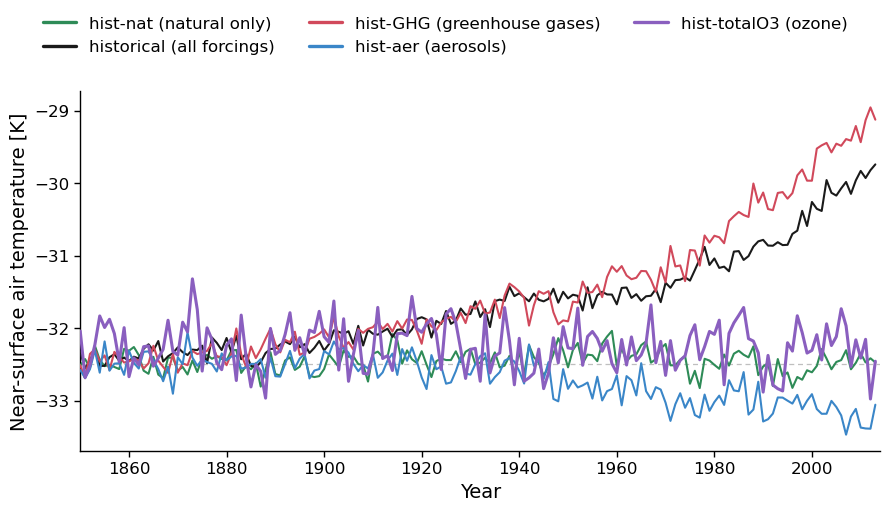

In [9]:
#(t): The ensemble means on the same axes, historical straight after hist-nat, then zoomed in
mean_order = [f for f in ['hist-nat', 'historical', 'hist-GHG', 'hist-aer', 'hist-totalO3'] if f in ensemble_mean]
mean_dir = SLIDE_DIR / 'buildup_ensemble_mean'
with plt.rc_context(SLIDE_RC):
    for step in range(1, len(mean_order) + 1):
        panels = figures.tas_buildup_figure(ensemble_mean, mean_order[:step], ylim, order=mean_order, baseline=baseline)
        utils.save_frame(panels.fig, mean_dir, step, mean_order[step - 1])
    zoom = utils.shared_ylim([da.values for da in ensemble_mean.values()], include=[baseline])
    panels = figures.tas_buildup_figure(ensemble_mean, mean_order, zoom, order=mean_order, baseline=baseline,
                                        fade_earlier=False)
    utils.save_frame(panels.fig, mean_dir, len(mean_order) + 1, 'zoom', close=False)

## Historical against hist-nat

Every member, then the same as quantile plumes: the rolling 21-year quantiles of all members pooled, in nested bands from the 10–90% range to the 40–60% range around the median.

In [10]:
PLUME_QUANTILES = np.round(np.arange(0.1, 1, 0.1), 2)
QUANTILE_PAIRS = np.array(list(zip(PLUME_QUANTILES[:len(PLUME_QUANTILES) // 2], PLUME_QUANTILES[::-1]))).round(2)

point_quantiles_da = datatree.reduce_to_dataset(
    point_tree,
    partial(qc.rolling_quantile, rolling_dim='year', window=config.WINDOW, quantiles=PLUME_QUANTILES,
            extra_dims=['member']),
    dims=['experiment'],
)[VARIABLE].compute()
historical_quantiles_da = point_quantiles_da.sel(experiment='historical', season=SLIDE_SEASON)
histnat_quantiles_da = point_quantiles_da.sel(experiment='hist-nat', season=SLIDE_SEASON)
label_x = historical_quantiles_da.year.values[-1]
QUANTILE_PAIRS

array([[0.1, 0.9],
       [0.2, 0.8],
       [0.3, 0.7],
       [0.4, 0.6]])

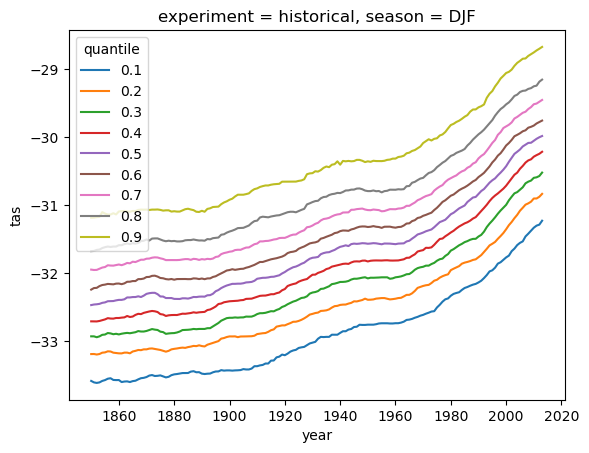

In [11]:
#(t): Quick look: historical's rolling quantiles (the plume's band edges), one line per quantile
historical_quantiles_da.plot.line(x='year', hue='quantile');

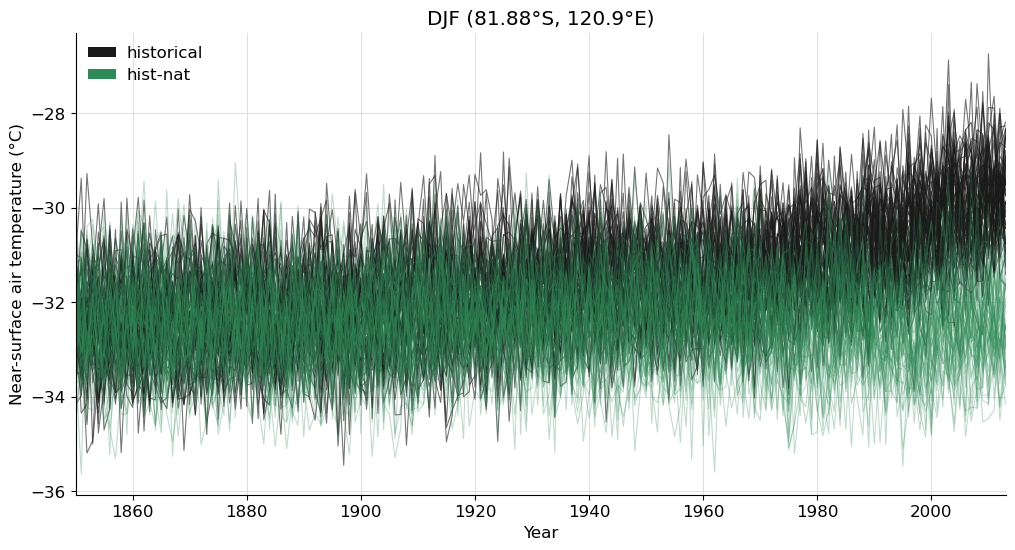

In [12]:
#(t): Every member
fig, ax = plt.subplots(figsize=(12, 6))
for forcing, alpha in [('historical', 0.6), ('hist-nat', 0.3)]:
    ax.plot(point_members[forcing].year, point_members[forcing].transpose('year', 'member'),
            color=FORCING_COLORS[forcing], alpha=alpha, lw=0.8)
ax.legend(handles=[Patch(facecolor=FORCING_COLORS[f], label=f) for f in ('historical', 'hist-nat')],
          loc='upper left', frameon=False)
ax.set(xlabel='Year', ylabel=var.label, title=f'{SLIDE_SEASON} ({POINT_LABEL})')
formatting.style_ax(ax, scale=1.2)
fig.savefig(SLIDE_DIR / 'plume_lines.png', dpi=250, bbox_inches='tight')

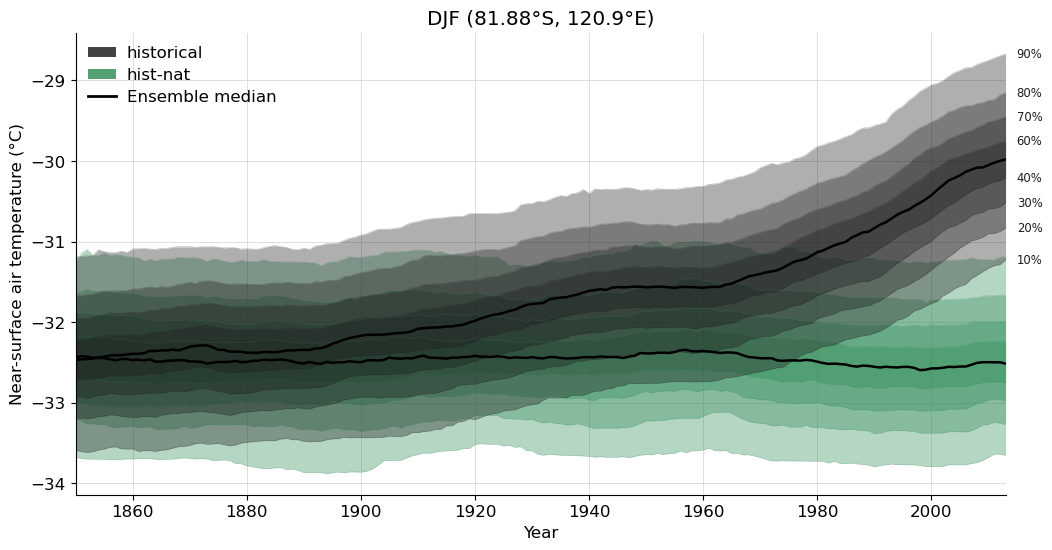

In [13]:
#(t): As quantile plumes, with the band edges labelled
fig, ax = plt.subplots(figsize=(12, 6))
timeseries.draw_plume(ax, histnat_quantiles_da, QUANTILE_PAIRS, color=FORCING_COLORS['hist-nat'], edge_widths=0.2,
                      median_color='k')
timeseries.draw_plume(ax, historical_quantiles_da, QUANTILE_PAIRS, color=FORCING_COLORS['historical'], edge_widths=0.2,
                      median_color='k')
core_alpha = 1 - np.prod([1 - band.get_facecolor()[0][3] for band in ax.collections[:len(QUANTILE_PAIRS)]])
ax.legend(handles=[Patch(facecolor=FORCING_COLORS['historical'], alpha=core_alpha, label='historical'),
                   Patch(facecolor=FORCING_COLORS['hist-nat'], alpha=core_alpha, label='hist-nat'),
                   Line2D([], [], color='k', lw=2, label='Ensemble median')], loc='upper left', frameon=False)
label_band_edges(ax, historical_quantiles_da, QUANTILE_PAIRS, label_x, color=FORCING_COLORS['historical'], fontsize='small')
ax.set(xlabel='Year', ylabel=var.label, title=f'{SLIDE_SEASON} ({POINT_LABEL})')
formatting.style_ax(ax, scale=1.2)
fig.subplots_adjust(right=0.90)
fig.savefig(SLIDE_DIR / 'plume_percentiles.png', dpi=250, bbox_inches='tight')

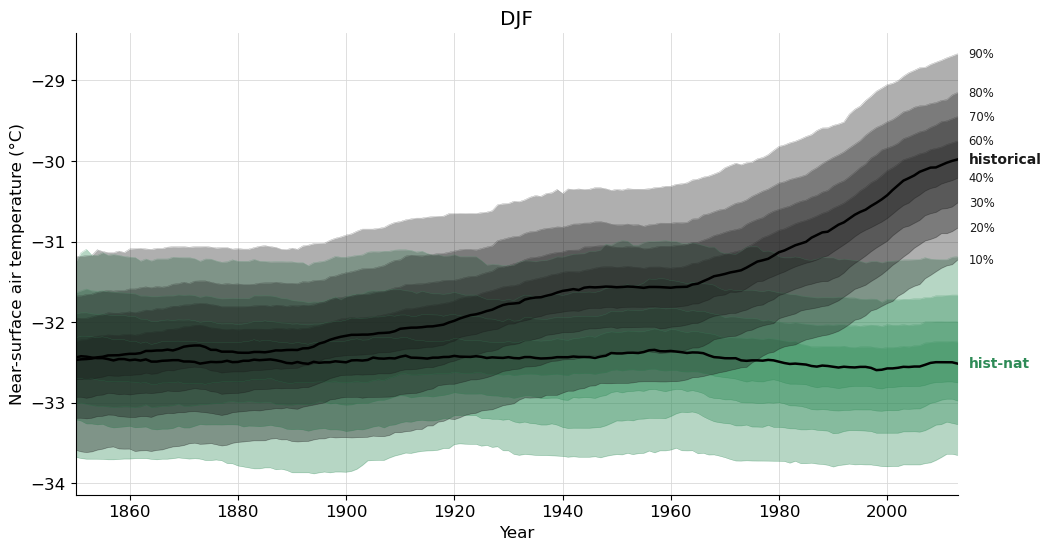

In [14]:
#(t): The same, labelled with the experiment names instead of a legend
fig, ax = plt.subplots(figsize=(12, 6))
timeseries.draw_plume(ax, histnat_quantiles_da, QUANTILE_PAIRS, color=FORCING_COLORS['hist-nat'], edge_widths=0.2,
                      median_color='k')
timeseries.draw_plume(ax, historical_quantiles_da, QUANTILE_PAIRS, color=FORCING_COLORS['historical'], edge_widths=0.2,
                      median_color='k')
for forcing, quantiles_da in [('historical', historical_quantiles_da), ('hist-nat', histnat_quantiles_da)]:
    label_line_end(ax, label_x, quantiles_da.sel(quantile=0.5, method='nearest').isel(year=-1), forcing,
                   FORCING_COLORS[forcing], fontweight='bold')
label_band_edges(ax, historical_quantiles_da, QUANTILE_PAIRS, label_x, color=FORCING_COLORS['historical'], fontsize='small')
ax.set(xlabel='Year', ylabel=var.label, title=SLIDE_SEASON)
formatting.style_ax(ax, scale=1.2)
fig.subplots_adjust(right=0.86)
fig.savefig(SLIDE_DIR / 'plume_labelled.png', dpi=250, bbox_inches='tight')

## How the forced-response figures are made

Three pictures for a talk about notebooks 04 and 06: where a count of models comes from, how to read the joint colours, and the forcings' changes revealed one at a time. They use notebook 03's saved results.

In [15]:
#(t): The member-block test of the mean change (notebook 03, section 4)
mean_block_ds = storage.open_dataset(paths.result('mean_block', VARIABLE, RUN), load=True)
mean_block_ds

13:27:59 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/mean_block.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


<xarray.Dataset> Size: 3MB
Dimensions:      (model: 6, season: 4, lat: 20, experiment: 4, lon: 144)
Coordinates:
  * model        (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * season       (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat          (lat) float64 160B -87.5 -85.0 -82.5 ... -45.0 -42.5 -40.0
  * experiment   (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * lon          (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
Data variables:
    mean_change  (lat, lon, season, model, experiment) float32 1MB 2.339 ... ...
    pvalue       (lat, lon, season, model, experiment) float64 2MB 0.0003999 ...

In [16]:
#(t): The width test (notebook 03, section 2)
qrange_change_ds = storage.open_dataset(paths.result('qrange_change', VARIABLE, RUN), load=True)

13:27:59 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/qrange_change.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


### Counting the models

At `SLIDE_POINT` in `SLIDE_SEASON`: each model's final 21 years of hist-nat and of `SLIDE_EXPERIMENT` (members and years pooled), the member-block test of the change in their means, and its verdict. Counted, the verdicts give the number on the count map (notebook 04, section 1.4) at the starred point.

In [18]:
SLIDE_POINT

{'lat': -81.88, 'lon': 120.9, 'method': 'nearest'}

In [19]:
lesfmip_season_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (member: 50, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 378MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (member: 30, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 227MB dask.array<chunksize=(30, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (member: 50, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 378MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (member: 10, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 76MB dask.array<chunksize=(10, 4, 144, 164, 4), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (member: 65, lat: 20, lon: 144, year: 164, season: 4)
│           Coordinates:
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│             * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│           Data variables:
│               tas      (member, lat, lon, year, season) float32 491MB dask.array<chunksize=(65, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (member: 45, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0

In [17]:
#(t): Every model at the point
all_models_point_tree = lesfmip_season_tree.sel(**SLIDE_POINT)
all_models_point_tree

ValueError: cannot supply selection options {'method': 'nearest', 'tolerance': None} for dimension 'lon'that has no associated coordinate or index

In [ ]:
#(t): in SLIDE_SEASON
all_models_season_tree = all_models_point_tree.sel(season=SLIDE_SEASON)

In [ ]:
#(t): over the final WINDOW years, loaded into memory (a few kB)
point_final_tree = all_models_season_tree.isel(year=slice(-WINDOW, None)).load()

In [ ]:
#(t): hist-nat's values in each model, on (member, year)
point_hist_nat = {node.parent.name: node[VARIABLE] for node in point_final_tree.match('*/hist-nat').leaves}
list(point_hist_nat)

In [ ]:
#(t): SLIDE_EXPERIMENT's
point_experiment = {node.parent.name: node[VARIABLE] for node in point_final_tree.match(f'*/{SLIDE_EXPERIMENT}').leaves}
list(point_experiment)

In [ ]:
#(t): The test at the point, every model: the change in the mean and its p-value
point_test_ds = mean_block_ds.sel(experiment=SLIDE_EXPERIMENT, season=SLIDE_SEASON).sel(**SLIDE_POINT)
point_test_ds.to_dataframe()[['mean_change', 'pvalue']]

In [ ]:
#(t): The test everywhere, SLIDE_EXPERIMENT in SLIDE_SEASON
season_test_ds = mean_block_ds.sel(experiment=SLIDE_EXPERIMENT, season=SLIDE_SEASON)

In [ ]:
#(t): How many models have a significant increase, and a decrease, at every point
slide_counts_da = sig.significant_counts(season_test_ds['mean_change'], season_test_ds['pvalue'] < ALPHA)
slide_counts_da

In [ ]:
panels = slides.count_schematic(
    point_hist_nat, point_experiment, point_test_ds['mean_change'], point_test_ds['pvalue'], slide_counts_da,
    {'lat': float(point_test_ds['lat']), 'lon': float(point_test_ds['lon'])}, SLIDE_EXPERIMENT, alpha=ALPHA,
    units=var.units,
    title=f'From one test per model to a count: {SLIDE_EXPERIMENT}, {SLIDE_SEASON} at {POINT_LABEL}',
)

In [ ]:
panels.fig.savefig(SLIDE_DIR / 'count_schematic.png', dpi=250, bbox_inches='tight')

### Reading the joint colours

The 3 × 3 key of the joint maps (notebook 04 section 5, notebook 06 Fig. 4), each colour drawn as what it means for the distribution: shifted down, not or up, and narrower, the same or wider.

In [ ]:
panels = slides.joint_key_explainer(scales.joint)

In [ ]:
panels.fig.savefig(SLIDE_DIR / 'joint_key.png', dpi=250, bbox_inches='tight')

### The forcings one at a time

The multi-model median change in the mean and in the width, every season, with one forcing added per frame (the order of `EXPERIMENTS`), dotted where fewer than two-thirds of the models have a significant change of one sign. Every frame has the same canvas, so they can be flipped through.

In [20]:
#(t): The multi-model median change in the mean
median_mean_change_da = mean_block_ds['mean_change'].median('model')
median_mean_change_da

<xarray.DataArray 'mean_change' (lat: 20, lon: 144, season: 4, experiment: 4)> Size: 184kB
1.55 -0.4011 0.05572 0.8298 1.446 -0.3345 ... 0.6099 1.018 -0.2448 0.1042 0.543
Coordinates:
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5

In [21]:
#(t): Where the models agree on a significant change in the mean
mean_robust_sign_da = sig.robust_sign(mean_block_ds['mean_change'], mean_block_ds['pvalue'] < ALPHA, threshold=ROBUST)

In [22]:
#(t): Not robust: the dots
mean_not_robust_da = mean_robust_sign_da == 0

In [23]:
#(t): The frames: the mean
mean_frames = slides.reveal_frames(
    median_mean_change_da.sel(experiment=EXPERIMENTS, season=SEASONS), scales.change, SLIDE_DIR / 'reveal_mean_change',
    not_significant=mean_not_robust_da.sel(experiment=EXPERIMENTS, season=SEASONS),
    title='Change in the mean, final 21 years against hist-nat (multi-model median)',
    not_significant_label='Not robust (fewer than 2/3 of the models significant)',
)
[frame.name for frame in mean_frames]

['01_hist-GHG.png',
 '02_hist-aer.png',
 '03_hist-totalO3.png',
 '04_historical.png']

In [24]:
#(t): The multi-model median change in the width
median_width_change_da = qrange_change_ds['qrange_change'].median('model')

In [25]:
#(t): Where the models agree on a significant change in the width
width_robust_sign_da = sig.robust_sign(qrange_change_ds['qrange_change'], qrange_change_ds['qrange_significant'],
                                       threshold=ROBUST)

In [26]:
#(t): Not robust: the dots
width_not_robust_da = width_robust_sign_da == 0

In [27]:
#(t): The frames: the width
width_frames = slides.reveal_frames(
    median_width_change_da.sel(experiment=EXPERIMENTS, season=SEASONS), scales.spread_change,
    SLIDE_DIR / 'reveal_width_change',
    not_significant=width_not_robust_da.sel(experiment=EXPERIMENTS, season=SEASONS),
    title='Change in the width Q95 − Q05, final 21 years against hist-nat (multi-model median)',
    not_significant_label='Not robust (fewer than 2/3 of the models significant)',
)
[frame.name for frame in width_frames]

['01_hist-GHG.png',
 '02_hist-aer.png',
 '03_hist-totalO3.png',
 '04_historical.png']